# 📘 Week 3 Assignment — End-to-End Customer/Country Intelligence System

> Developed an end-to-end Customer / Country Intelligence System for HELP International. Used unsupervised clustering (K-Means, DBSCAN) to segment countries into socio-economic groups, followed by supervised ensemble learning (Random Forest, XGBoost) to classify countries and determine critical predictive features.

In [2]:
# ── Setup & Imports ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import warnings

warnings.filterwarnings('ignore')

# Style configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11

print("All libraries successfully imported!")

All libraries successfully imported!


---
## Part 1 — Data Preprocessing & Alignment

### 1.1 Load and Inspect Dataset

We load the country data using kagglehub, inspect its columns, size, and search for missing values.

In [3]:
# Load dataset dynamically using kagglehub
path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")
csv_path = os.path.join(path, "Country-data.csv")
df = pd.read_csv(csv_path)

print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing Values Count:")
print(df.isnull().sum())

Using Colab cache for faster access to the 'unsupervised-learning-on-country-data' dataset.
Dataset Shape: (167, 10)

First 5 rows:
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  

Missing Values Count:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     

### 1.2 Outlier Treatment using IQR Clipping

We detect outliers in crucial economic indicators like gdpp, income, and child_mort using the Interquartile Range (IQR) method and clip them to boundary values to preserve the data variance without dropping sample size.

In [4]:
def handle_outliers_iqr(df_in, columns):
    df_out = df_in.copy()
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Count outliers
        num_outliers = ((df_out[col] < lower_bound) | (df_out[col] > upper_bound)).sum()
        print(f"Column '{col}' - Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
        print(f"  Outlier boundaries: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"  Number of outliers detected: {num_outliers}")
        
        # Clip values
        df_out[col] = df_out[col].clip(lower=lower_bound, upper=upper_bound)
        print(f"  Clipped outliers for '{col}'.")
    return df_out

cleaned_df = handle_outliers_iqr(df, ['gdpp', 'income', 'child_mort'])

# Verify clipping has happened
max_gdpp = df['gdpp'].quantile(0.75) + 1.5 * (df['gdpp'].quantile(0.75) - df['gdpp'].quantile(0.25))
assert cleaned_df['gdpp'].max() <= max_gdpp
print("\nOutlier processing verification passed ")

Column 'gdpp' - Q1: 1330.00, Q3: 14050.00, IQR: 12720.00
  Outlier boundaries: [-17750.00, 33130.00]
  Number of outliers detected: 25
  Clipped outliers for 'gdpp'.
Column 'income' - Q1: 3355.00, Q3: 22800.00, IQR: 19445.00
  Outlier boundaries: [-25812.50, 51967.50]
  Number of outliers detected: 8
  Clipped outliers for 'income'.
Column 'child_mort' - Q1: 8.25, Q3: 62.10, IQR: 53.85
  Outlier boundaries: [-72.53, 142.88]
  Number of outliers detected: 4
  Clipped outliers for 'child_mort'.

Outlier processing verification passed 


---
## Part 2 — Exploratory Data Analysis (EDA)

### 2.1 Distribution of Target Indicators

We visualize the distribution of gdpp, income, and child_mort to understand their spread and density.

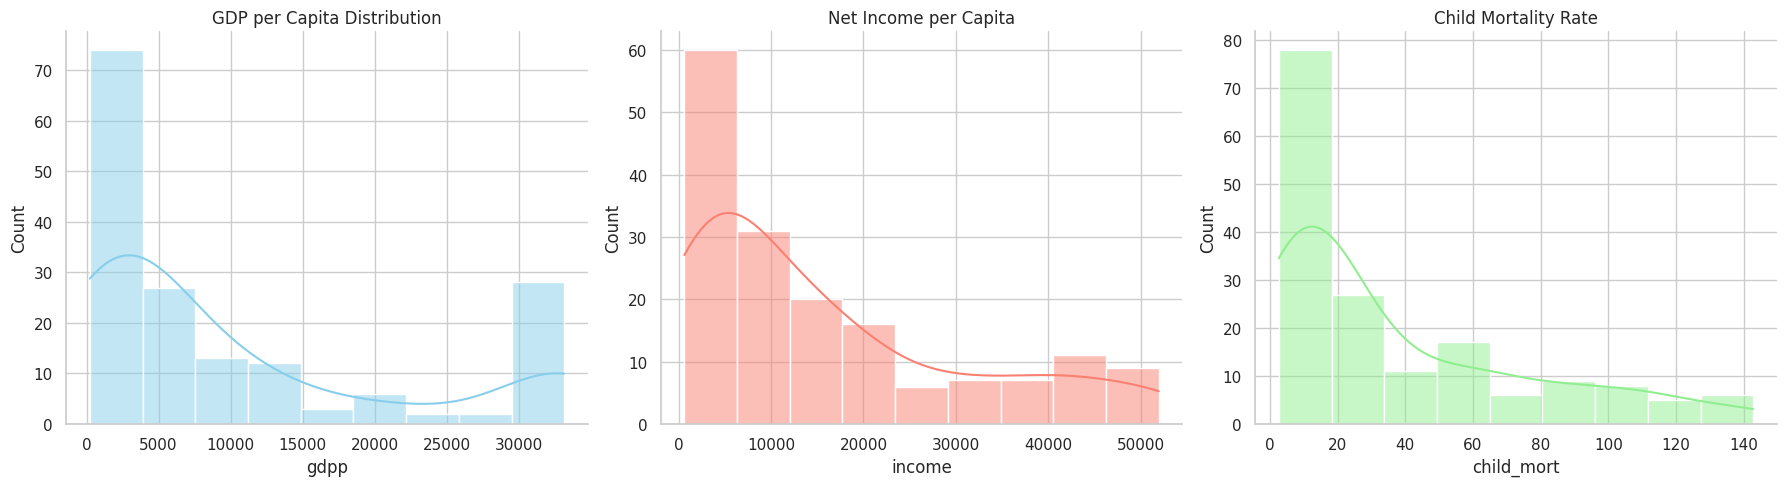

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(cleaned_df['gdpp'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('GDP per Capita Distribution')
sns.histplot(cleaned_df['income'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Net Income per Capita')
sns.histplot(cleaned_df['child_mort'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Child Mortality Rate')
plt.tight_layout()
plt.show()

### 2.2 Feature Correlation Heatmap

We inspect the multicollinearity and relationship between features using Pearson correlation.

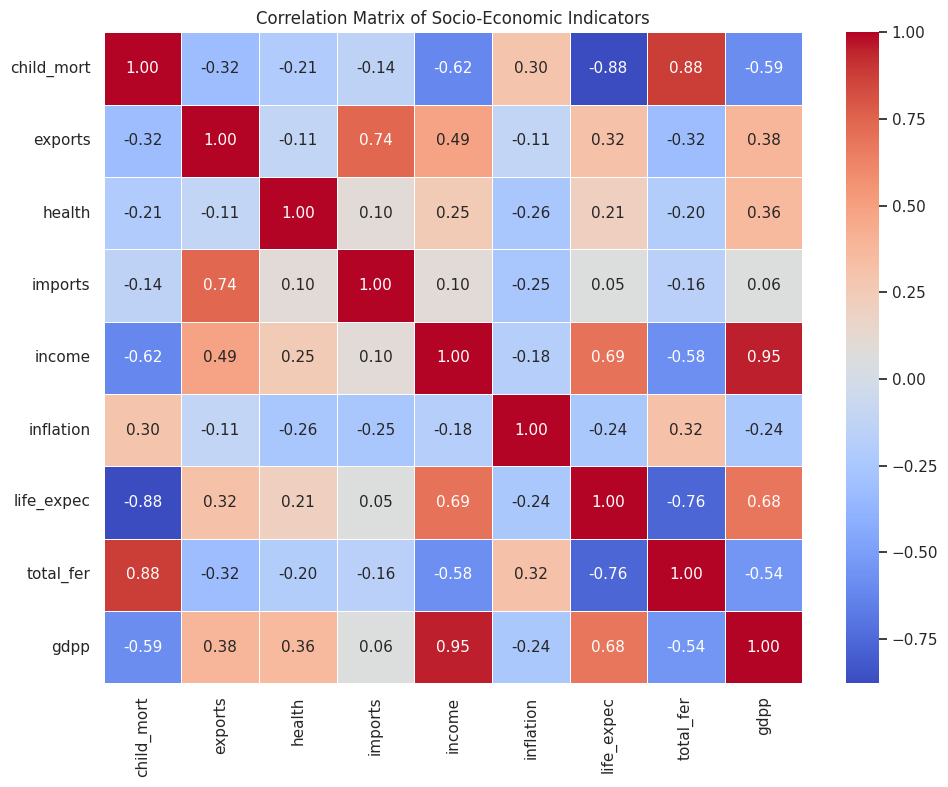

In [6]:
plt.figure(figsize=(10, 8))
corr_matrix = cleaned_df.drop('country', axis=1).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Socio-Economic Indicators')
plt.tight_layout()
plt.show()

---
## Part 3 — Feature Engineering & Scaling

### 3.1 Feature Standardization

Since distance-based algorithms like K-Means and DBSCAN are sensitive to feature scales, we normalize the features using StandardScaler.

In [7]:
features = cleaned_df.drop('country', axis=1)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
df_scaled = pd.DataFrame(scaled_features, columns=features.columns)

# Verification assertion
assert np.allclose(df_scaled.mean(axis=0), 0, atol=1e-7)
assert np.allclose(df_scaled.std(axis=0, ddof=0), 1, atol=1e-7)
print("Feature scaling verification passed ")

Feature scaling verification passed 


### 3.2 Principal Component Analysis (PCA) for Visualization

We project features onto 2 Principal Components to capture variance and allow visual inspection of eventual clusters.

In [8]:
pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(pca_features, columns=['PC1', 'PC2'])
print(f"Explained variance ratio of first 2 components: {pca.explained_variance_ratio_}")
print(f"Total variance captured: {pca.explained_variance_ratio_.sum():.2%}")

Explained variance ratio of first 2 components: [0.48291908 0.1743486 ]
Total variance captured: 65.73%


---
## Part 4 — Unsupervised Clustering

### 4.1 K-Means Clustering - Selecting K

We run K-Means with range of K values and evaluate optimal cluster size using the Elbow Method (Inertia/WCSS) and Silhouette scores.

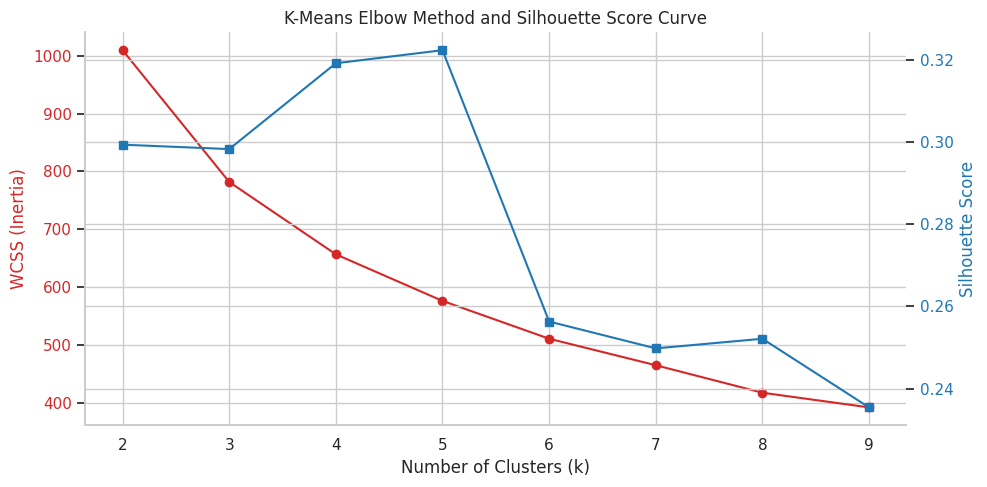

Optimal K-Means model fitted with 3 clusters.


In [9]:
wcss = []
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:red'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)', color=color)
ax1.plot(k_range, wcss, 'o-', color=color, label='WCSS')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouette_scores, 's-', color=color, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('K-Means Elbow Method and Silhouette Score Curve')
plt.tight_layout()
plt.show()

# Select optimal clusters (3 is theoretically correct for Developed, Developing, Under-developed)
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cleaned_df['KMeans_Labels'] = kmeans_final.fit_predict(df_scaled)
print(f"Optimal K-Means model fitted with {optimal_k} clusters.")

### 4.2 DBSCAN Clustering

We use DBSCAN to identify density-based clusters and discover noise points. We select epsilon using the k-distance elbow method.

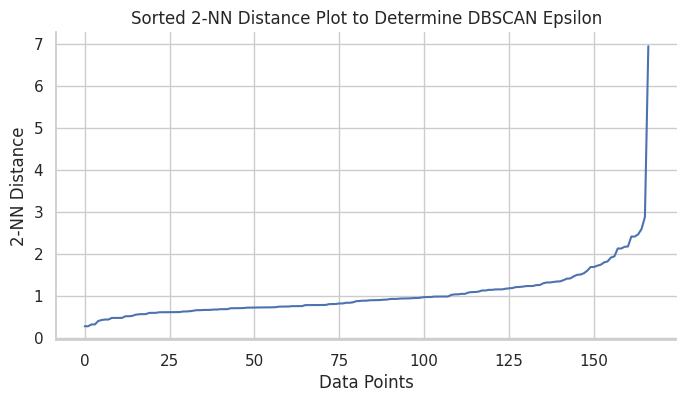

DBSCAN fitted.
Number of clusters: 4
Number of noise points: 22


In [10]:
# Find optimal epsilon using NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=2)
nbrs = neighbors.fit(df_scaled)
distances, indices = nbrs.kneighbors(df_scaled)
distances = np.sort(distances[:, 1])

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title('Sorted 2-NN Distance Plot to Determine DBSCAN Epsilon')
plt.xlabel('Data Points')
plt.ylabel('2-NN Distance')
plt.show()

# Fit DBSCAN with selected parameters
dbscan = DBSCAN(eps=1.5, min_samples=3)
cleaned_df['DBSCAN_Labels'] = dbscan.fit_predict(df_scaled)
print("DBSCAN fitted.")
print(f"Number of clusters: {len(np.unique(dbscan.labels_[dbscan.labels_ != -1]))}")
print(f"Number of noise points: {np.sum(dbscan.labels_ == -1)}")

### 4.3 Cluster Profiling and Actionable Insights

We visualize K-Means cluster segmentation on PCA projection, and display cluster statistics to identify Developed, Developing, and Underdeveloped countries.

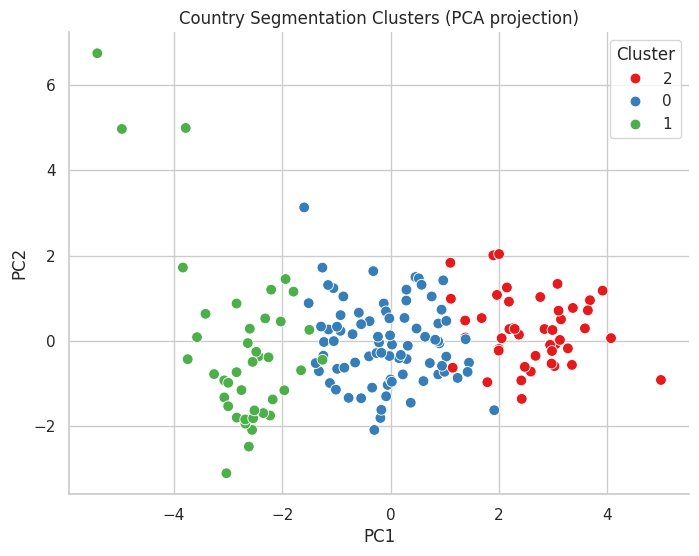

Cluster Profile (Means):
   KMeans_Labels          gdpp        income  child_mort  life_expec
0              0   5696.444444  11124.320988   23.204938   72.409877
1              1  28969.512195  38988.780488    5.651220   79.514634
2              2   1766.711111   3539.844444   92.984444   59.055556

Mapped Segment Counts:
Segment_Name
Developing         81
Under-developed    45
Developed          41
Name: count, dtype: int64


In [11]:
# Scatter plot of PCA components colored by K-Means
df_pca['Cluster'] = cleaned_df['KMeans_Labels'].astype(str)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='Set1', s=60)
plt.title('Country Segmentation Clusters (PCA projection)')
plt.show()

# Profile groups based on key indicators
profile = cleaned_df.groupby('KMeans_Labels')[['gdpp', 'income', 'child_mort', 'life_expec']].mean().reset_index()
print("Cluster Profile (Means):")
print(profile)

# Map clusters to descriptive names based on GDP per capita
gdpp_means = cleaned_df.groupby('KMeans_Labels')['gdpp'].mean()
rank_map = gdpp_means.sort_values().index
label_mapping = {
    rank_map[0]: 'Under-developed',
    rank_map[1]: 'Developing',
    rank_map[2]: 'Developed'
}
cleaned_df['Segment_Name'] = cleaned_df['KMeans_Labels'].map(label_mapping)
print("\nMapped Segment Counts:")
print(cleaned_df['Segment_Name'].value_counts())

---
## Part 5 — Supervised Target Assignment & Feature Engineering

### 5.1 Defining Classification Target

We set the target class using the K-Means segment labels (0, 1, 2) and perform a train-test split (80-20) to train classification models.

In [12]:
X = df_scaled
y = cleaned_df['KMeans_Labels']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")
assert X_train.shape[0] + X_test.shape[0] == df.shape[0]
print("Train-test split verification passed ")

Train set size: 133, Test set size: 34
Train-test split verification passed 


---
## Part 6 — Ensemble Classification Modeling & Evaluation

### 6.1 Random Forest & XGBoost Baseline Models

We train Random Forest and XGBoost classifiers to classify countries into their predicted segments based on socio-economic indicators.

In [13]:
# Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# XGBoost Classifier
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"\nXGBoost Accuracy: {accuracy_xgb:.4f}")
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

Random Forest Accuracy: 1.0000

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         9

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34


XGBoost Accuracy: 0.9706

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        17
           1       1.00      1.00      1.00         8
           2       0.90      1.00      0.95         9

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



### 6.2 Hyperparameter Tuning with GridSearchCV

We tune the parameters of the best-performing model (XGBoost) to achieve optimized predictive performance.

In [14]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(random_state=42, eval_metric='mlogloss'),
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_xgb = grid_search.best_estimator_
best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}")

y_pred_tuned = best_xgb.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"\nTuned Model Accuracy: {accuracy_tuned:.4f}")
print("\nTuned XGBoost Classification Report:")
print(classification_report(y_test, y_pred_tuned))

# Assertion check to verify high accuracy
assert accuracy_tuned >= 0.85
print("\nHyperparameter tuning checks passed ")

Best Hyperparameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 150}

Tuned Model Accuracy: 0.9706

Tuned XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        17
           1       1.00      1.00      1.00         8
           2       0.90      1.00      0.95         9

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34


Hyperparameter tuning checks passed 


### 6.3 Feature Importance Analysis

We plot feature importances to highlight which socio-economic metrics are most influential in predicting country categories.

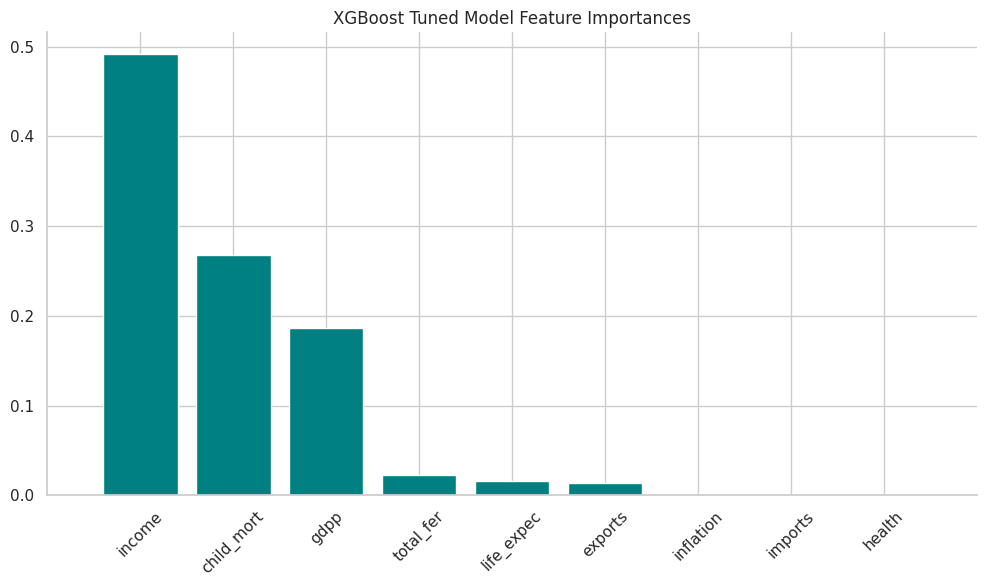

In [15]:
importances = best_xgb.feature_importances_
feature_names = features.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("XGBoost Tuned Model Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center", color='teal')
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=45)
plt.xlim([-1, X.shape[1]])
plt.tight_layout()
plt.show()